### Task 1:

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

insurance_df = pd.read_csv('insurance.csv')

- Largest range of values: Charges, 12k~ - 63k~
- age and bmi are similar in scale
- Because charges will be treated as heavily distant from the smaller scaled features

In [9]:
insurance_df.head()
print(insurance_df.shape)
insurance_df.describe()


(1338, 7)


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Task 2:

- The scatter plot clustering looks arbitrary, like it's just split into thirds.

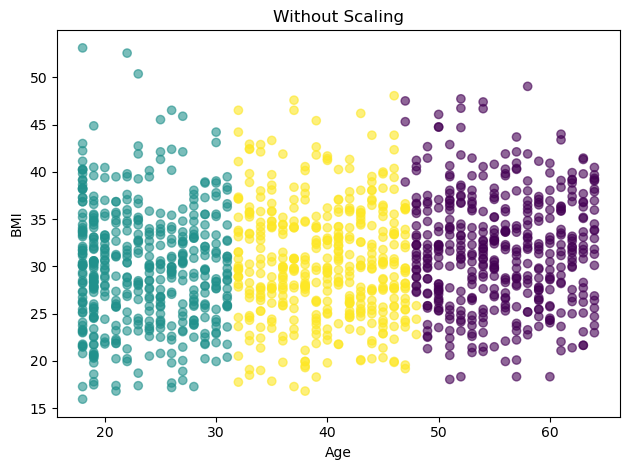

In [25]:
X = insurance_df[['age', 'bmi']]
unscaled_km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = unscaled_km.fit_predict(X)
insurance_df['unscaled_cluster'] = labels


plt.scatter(insurance_df['age'], insurance_df['bmi'], alpha=0.6, c=insurance_df['unscaled_cluster'], cmap='viridis')
plt.title('Without Scaling')
plt.xlabel('Age')
plt.ylabel('BMI')

plt.tight_layout()
plt.show()

### Task 3

- Our bands became vertical, and you see an interesting transition as older individuals receive higher charges.
- Scaling is important for K-Means as it measures distance, without it, there would be no reliable way for the model to measure how far one data point is from another.

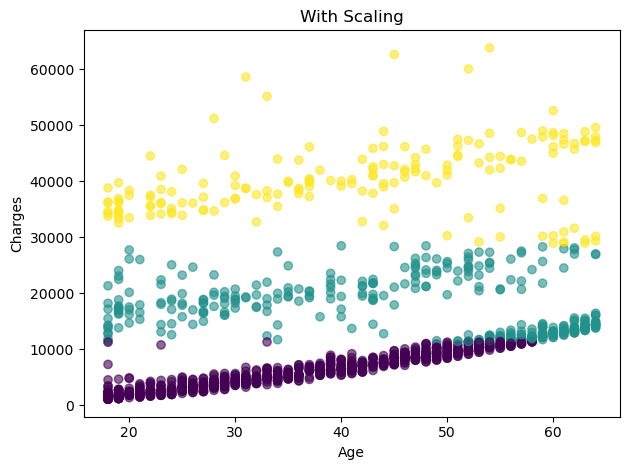

In [30]:
scaler = StandardScaler()
X = insurance_df[['age', 'bmi', 'charges']]
X_scaled = scaler.fit_transform(X)
scaled_km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = scaled_km.fit_predict(X)
insurance_df['scaled_cluster'] = labels

plt.scatter(insurance_df['age'], insurance_df['charges'], alpha=0.6, c=insurance_df['scaled_cluster'], cmap='viridis')
plt.title('With Scaling')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

### Task 4:

- The elbow appears between 3 and 4, this reflects a point in which there is a high enough quantity of clusters, that data points begin to cluster closer to their centroids.
- The highest silhouette score comes from k3, however, it is very close to k4, which offers a significant inertia reduction.
- Silhouette scores reflects how far points are from their nearest neighboring cluster. A higher score reflecting a greater distinction.

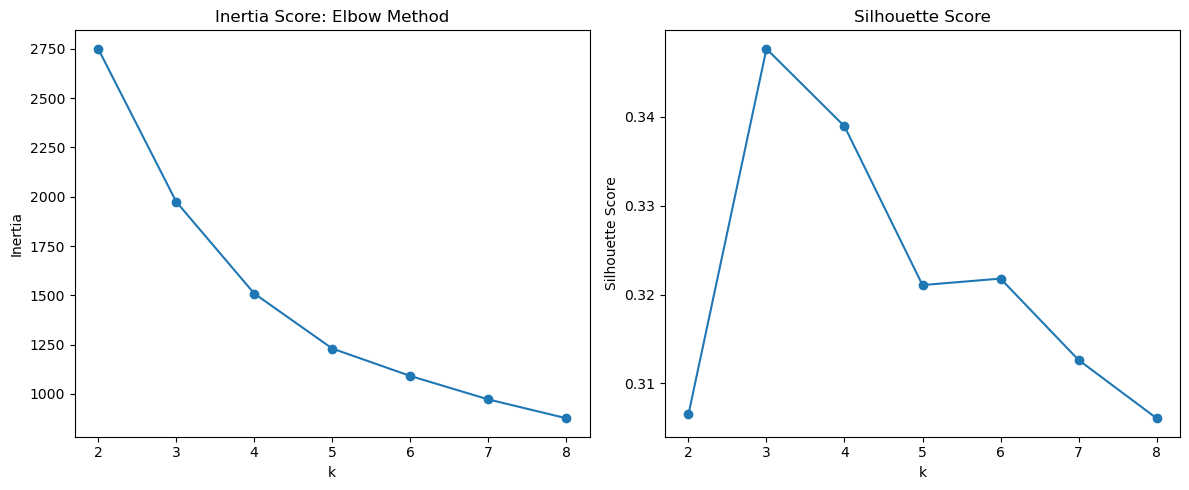

In [31]:
inertias = []
silhouette_scores = []
k_values = range(2, 9)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)  # it and return labels
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot both side by side.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(list(k_values), inertias, marker='o')
axes[0].set_title('Inertia Score: Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_values))

axes[1].plot(list(k_values), silhouette_scores, marker='o')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_values))

plt.tight_layout()
plt.show()